##Assignment 2_JRCAI: Customer Purchase Dataset

**Prepared by:** Madawi Alshebil  
**Email:** Madawi.alshebil@gmail.com  
**Supervisor:** Dr. Safwan Al-Selwi  
**Email:** saf1.alselwi@gmail.com



In [ ]:
import pandas as pd

# Read the CSV file
df = pd.read_csv("customer_purchase_dataset.csv")

# View the entire dataset
display(df)

,CustomerID,Age,Income,Gender,ProductCategory,Purchased
0,1,22.0,30000.0,Male,Electronics,Yes
1,2,34.0,45000.0,Female,Clothing,No
2,3,NaN,NaN,Female,Electronics,Yes
3,4,45.0,60000.0,Male,Furniture,Yes
4,5,23.0,35000.0,Female,Electronics,No
5,6,40.0,55000.0,Male,Appliances,Yes
6,7,31.0,40000.0,Female,Furniture,No
7,8,27.0,48000.0,Male,Clothing,Yes
8,9,52.0,65000.0,Female,Appliances,Yes
9,10,38.0,47000.0,Male,Clothing,No


In [ ]:
print("Dataset shape:", df.shape)

Dataset shape: (15, 6)


In [ ]:
print("\nColumn information:")
df.info()


Column information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerID       15 non-null     int64  
 1   Age              13 non-null     float64
 2   Income           13 non-null     float64
 3   Gender           15 non-null     object 
 4   ProductCategory  15 non-null     object 
 5   Purchased        15 non-null     object 
dtypes: float64(2), int64(1), object(3)
memory usage: 852.0+ bytes


##1. Data Preprocessing


In [ ]:
# Counting missing values in every column
print("Missing values in each column:")
print(df.isnull().sum())

# Counting duplicated rows
print("\nNumber of duplicated rows:")
print(df.duplicated().sum())

Missing values in each column:
CustomerID         0
Age                2
Income             2
Gender             0
ProductCategory    0
Purchased          0
dtype: int64

Number of duplicated rows:
0


In [ ]:
# Checking for impossible/ Negative Age values

invalid_age = df[(df["Age"] < 0) | (df["Age"] > 120)]
invalid_income = df[df["Income"] < 0]

display(invalid_age)
display(invalid_income)

,CustomerID,Age,Income,Gender,ProductCategory,Purchased


,CustomerID,Age,Income,Gender,ProductCategory,Purchased


In [ ]:
# Checking categorical values for spelling inconsistencies

print(df["Gender"].unique())

print(df["ProductCategory"].unique())

print(df["Purchased"].unique())

['Male' 'Female']
['Electronics' 'Clothing' 'Furniture' 'Appliances']
['Yes' 'No']


In [ ]:
# Cleaning the dataset


df_clean = df.copy() # Creating a cleaned copy of the dataset

df_clean["Age"] = df_clean["Age"].fillna(round(df_clean["Age"].mean())).astype(int)

df_clean["Income"] = df_clean["Income"].fillna(round(df_clean["Income"].mean())).astype(int)

display(df_clean)

,CustomerID,Age,Income,Gender,ProductCategory,Purchased
0,1,22,30000,Male,Electronics,Yes
1,2,34,45000,Female,Clothing,No
2,3,34,47154,Female,Electronics,Yes
3,4,45,60000,Male,Furniture,Yes
4,5,23,35000,Female,Electronics,No
5,6,40,55000,Male,Appliances,Yes
6,7,31,40000,Female,Furniture,No
7,8,27,48000,Male,Clothing,Yes
8,9,52,65000,Female,Appliances,Yes
9,10,38,47000,Male,Clothing,No


In [ ]:
# Encoding the categorical variables

df_encoded = df_clean.copy()

df_encoded["Gender"] = df_encoded["Gender"].map({"Female": 0,"Male": 1})

df_encoded["Purchased"] = df_encoded["Purchased"].map({"No": 0,"Yes": 1})

df_encoded = pd.get_dummies(df_encoded,columns=["ProductCategory"],dtype=int)

display(df_encoded)

,CustomerID,Age,Income,Gender,Purchased,ProductCategory_Appliances,ProductCategory_Clothing,ProductCategory_Electronics,ProductCategory_Furniture
0,1,22,30000,1,1,0,0,1,0
1,2,34,45000,0,0,0,1,0,0
2,3,34,47154,0,1,0,0,1,0
3,4,45,60000,1,1,0,0,0,1
4,5,23,35000,0,0,0,0,1,0
5,6,40,55000,1,1,1,0,0,0
6,7,31,40000,0,0,0,0,0,1
7,8,27,48000,1,1,0,1,0,0
8,9,52,65000,0,1,1,0,0,0
9,10,38,47000,1,0,0,1,0,0


In [ ]:
# Applying MinMaxScalar to Age and Income

from sklearn.preprocessing import MinMaxScaler

df_scaled = df_encoded.copy()
scaler = MinMaxScaler()

df_scaled[["Age", "Income"]] = scaler.fit_transform(df_scaled[["Age", "Income"]])

print("Final Cleaned and Scaled Dataset:")
display(df_scaled.round(3))

Final Cleaned and Scaled Dataset:


,CustomerID,Age,Income,Gender,Purchased,ProductCategory_Appliances,ProductCategory_Clothing,ProductCategory_Electronics,ProductCategory_Furniture
0,1,0.000,0.000,1,1,0,0,1,0
1,2,0.400,0.429,0,0,0,1,0,0
2,3,0.400,0.490,0,1,0,0,1,0
3,4,0.767,0.857,1,1,0,0,0,1
4,5,0.033,0.143,0,0,0,0,1,0
5,6,0.600,0.714,1,1,1,0,0,0
6,7,0.300,0.286,0,0,0,0,0,1
7,8,0.167,0.514,1,1,0,1,0,0
8,9,1.000,1.000,0,1,1,0,0,0
9,10,0.533,0.486,1,0,0,1,0,0


## 2. Basic Analysis

In [ ]:
# Calculating the mean of Age and Income
print(f"Mean Age: {df_encoded['Age'].mean():.2f}")
print(f"Mean Income: {df_encoded['Income'].mean():,.2f}")

Mean Age: 33.87
Mean Income: 47,153.87


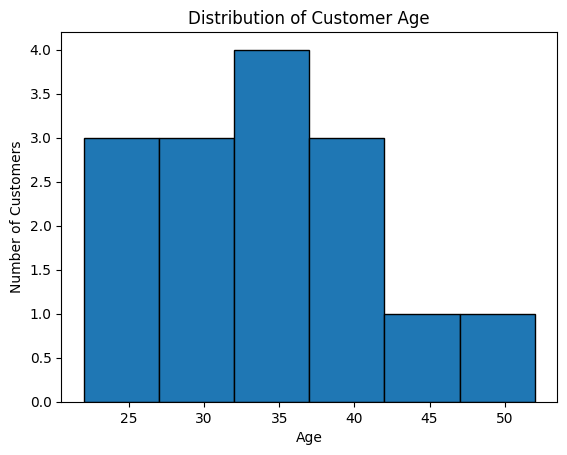

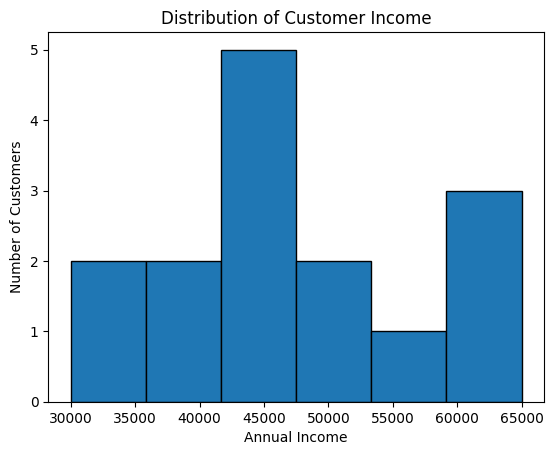

In [ ]:
# Creating histograms

import matplotlib.pyplot as plt

plt.hist(df_encoded["Age"], bins=6, edgecolor="black")
plt.title("Distribution of Customer Age")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.show()

plt.hist(df_encoded["Income"], bins=6, edgecolor="black")
plt.title("Distribution of Customer Income")
plt.xlabel("Annual Income")
plt.ylabel("Number of Customers")
plt.show()

## 3. Modeling

In [ ]:
# Preparing the model variables

X = df_encoded.drop(columns=["CustomerID", "Purchased"]) #input variables

y = df_encoded["Purchased"] #target variable

# Creating the Decision Tree model
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(max_depth=1,random_state=42)

In [ ]:
X

,Age,Income,Gender,ProductCategory_Appliances,ProductCategory_Clothing,ProductCategory_Electronics,ProductCategory_Furniture
0,22,30000,1,0,0,1,0
1,34,45000,0,0,1,0,0
2,34,47154,0,0,0,1,0
3,45,60000,1,0,0,0,1
4,23,35000,0,0,0,1,0
5,40,55000,1,1,0,0,0
6,31,40000,0,0,0,0,1
7,27,48000,1,0,1,0,0
8,52,65000,0,1,0,0,0
9,38,47000,1,0,1,0,0


In [ ]:
y

,Purchased
0,1
1,0
2,1
3,1
4,0
5,1
6,0
7,1
8,1
9,0


## 4. Evaluation

In [ ]:
# Using five-fold cross-validation to test the model and displaying the accuracy
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import accuracy_score

# Create five-fold cross-validation
cv = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)

# Generate predictions
predictions = cross_val_predict(model,X,y,cv=cv)

# Calculate accuracy
accuracy = accuracy_score(y, predictions)

print(f"Decision Tree Accuracy: {accuracy * 100:.2f}%")

Decision Tree Accuracy: 73.33%


In [ ]:
# Calculating the accuracy after scaling

X_scaled = df_scaled.drop(columns=["CustomerID", "Purchased"])

scaled_predictions = cross_val_predict(model,X_scaled,y,cv=cv)

scaled_accuracy = accuracy_score(y, scaled_predictions)

# Compare accuracy before and after scaling
accuracy_comparison = pd.DataFrame({
    "Model": ["Before Scaling","After MinMax Scaling"],"Accuracy": [f"{accuracy * 100:.2f}%",f"{scaled_accuracy * 100:.2f}%"]})

display(accuracy_comparison)

,Model,Accuracy
0,Before Scaling,73.33%
1,After MinMax Scaling,73.33%


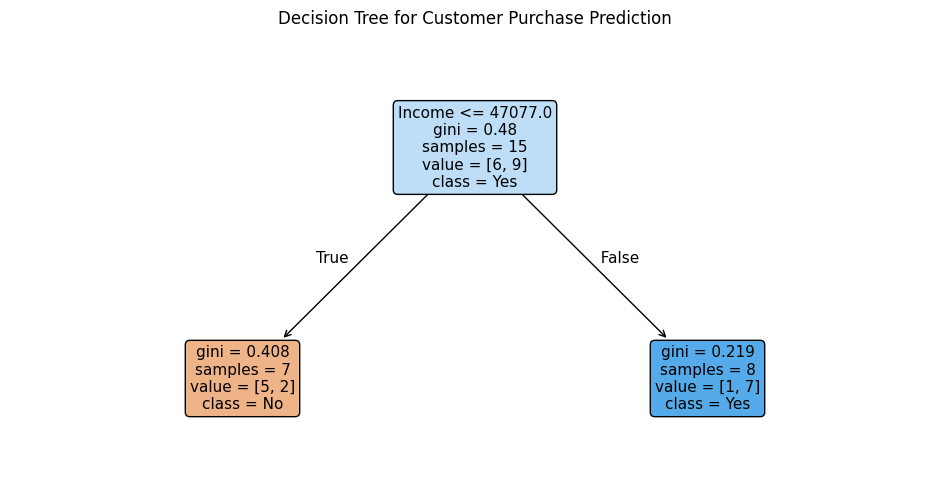

In [ ]:

# Decision tree visualization

from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Train the model on the complete dataset for visualization
model.fit(X, y)

plt.figure(figsize=(12, 6))

plot_tree(model,feature_names=X.columns,class_names=["No", "Yes"],filled=True,rounded=True,fontsize=11)

plt.title("Decision Tree for Customer Purchase Prediction")
plt.show()

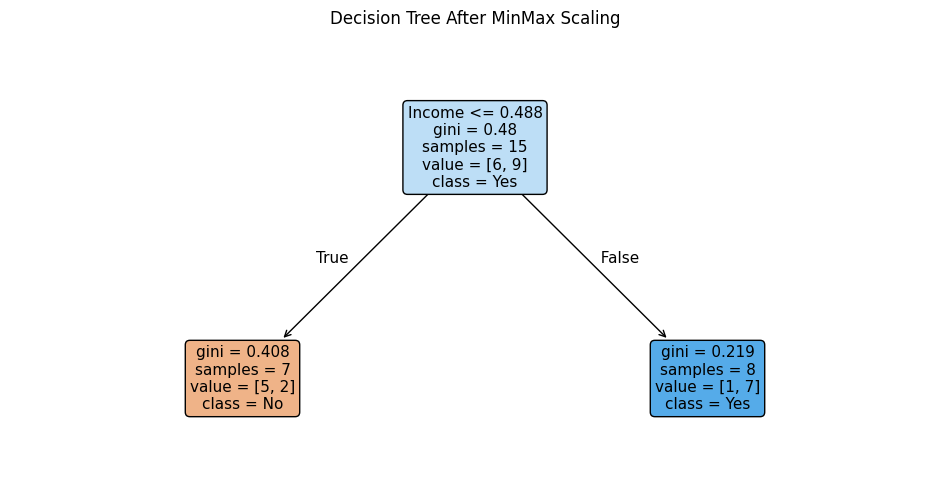

In [ ]:

# Training and visualizing the final scaled model

# Train the final Decision Tree using the already scaled dataset
final_scaled_model = DecisionTreeClassifier(max_depth=1,random_state=42)

final_scaled_model.fit(X_scaled, y)

# Visualize the final Decision Tree
plt.figure(figsize=(12, 6))

plot_tree(
    final_scaled_model,
    feature_names=X_scaled.columns,
    class_names=["No", "Yes"],
    filled=True,
    rounded=True,
    fontsize=11)

plt.title("Decision Tree After MinMax Scaling")
plt.show()